In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carica la rete ciclabile
fietsen = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\fietsnetten_geojson_lnglat.json")
print(f"Elementi caricati: {len(fietsen)}")
print(fietsen.columns.tolist())

Elementi caricati: 8391
['Label', 'Soort', 'Soortcode', 'Richtingen', 'Verharding', 'HoofdPlus', 'Stadsdeel', 'Lengte_m', 'geometry']


In [2]:
totale_km = fietsen['Lengte_m'].sum() / 1000
print(f"Lunghezza totale rete ciclabile: {totale_km:.1f} km")

# Vediamo i tipi di pista
print("\nTipi di pista ciclabile:")
print(fietsen['Soort'].value_counts())

Lunghezza totale rete ciclabile: 1742.6 km

Tipi di pista ciclabile:
Soort
Fietspad                                1770
Fietsoversteek                          1730
Brom-/Fietspad                          1326
Fietspad (snorfiets niet toegestaan)    1316
Fiets op rijbaan                        1178
Fietsstrook                              587
Verbinding                               244
Shared space                             147
Fietsstraat                               56
Fietspad (onverplicht)                    37
Name: count, dtype: int64


In [3]:
km_per_stadsdeel = fietsen.groupby('Stadsdeel')['Lengte_m'].sum() / 1000
km_per_stadsdeel = km_per_stadsdeel.sort_values(ascending=False).round(1)
print(km_per_stadsdeel)

Stadsdeel
X    447.6
F    316.4
N    263.8
K    174.8
M    165.2
T    113.5
E    107.0
A     91.9
B     47.2
S     15.1
Name: Lengte_m, dtype: float64


In [4]:
codici = {
    'A': 'Centrum',
    'B': 'Westpoort',
    'E': 'West',
    'F': 'Nieuw-West',
    'K': 'Zuid',
    'M': 'Oost',
    'N': 'Noord',
    'S': 'Amstelveen',
    'T': 'Zuidoost',
    'X': 'Nieuw-West (ext)'
}

km_per_stadsdeel.index = km_per_stadsdeel.index.map(lambda x: codici.get(x, x))
print(km_per_stadsdeel)

Stadsdeel
Nieuw-West (ext)    447.6
Nieuw-West          316.4
Noord               263.8
Zuid                174.8
Oost                165.2
Zuidoost            113.5
West                107.0
Centrum              91.9
Westpoort            47.2
Amstelveen           15.1
Name: Lengte_m, dtype: float64


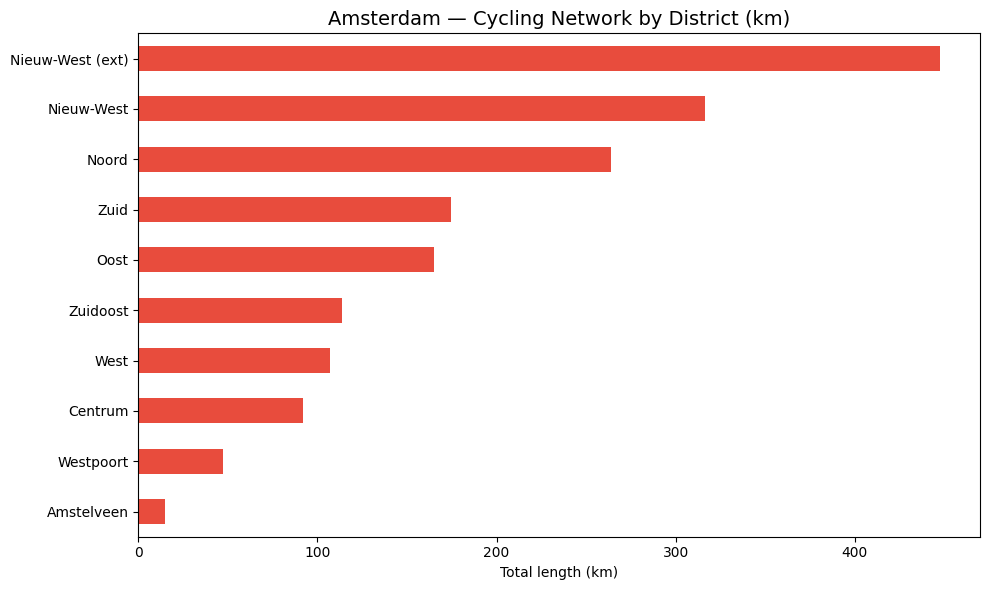

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

km_per_stadsdeel.sort_values().plot(
    kind='barh',
    color='#E84C3D',
    ax=ax
)

ax.set_title('Amsterdam — Cycling Network by District (km)', fontsize=14)
ax.set_xlabel('Total length (km)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('amsterdam_cycling_chart.png', dpi=150, bbox_inches='tight')
plt.show()

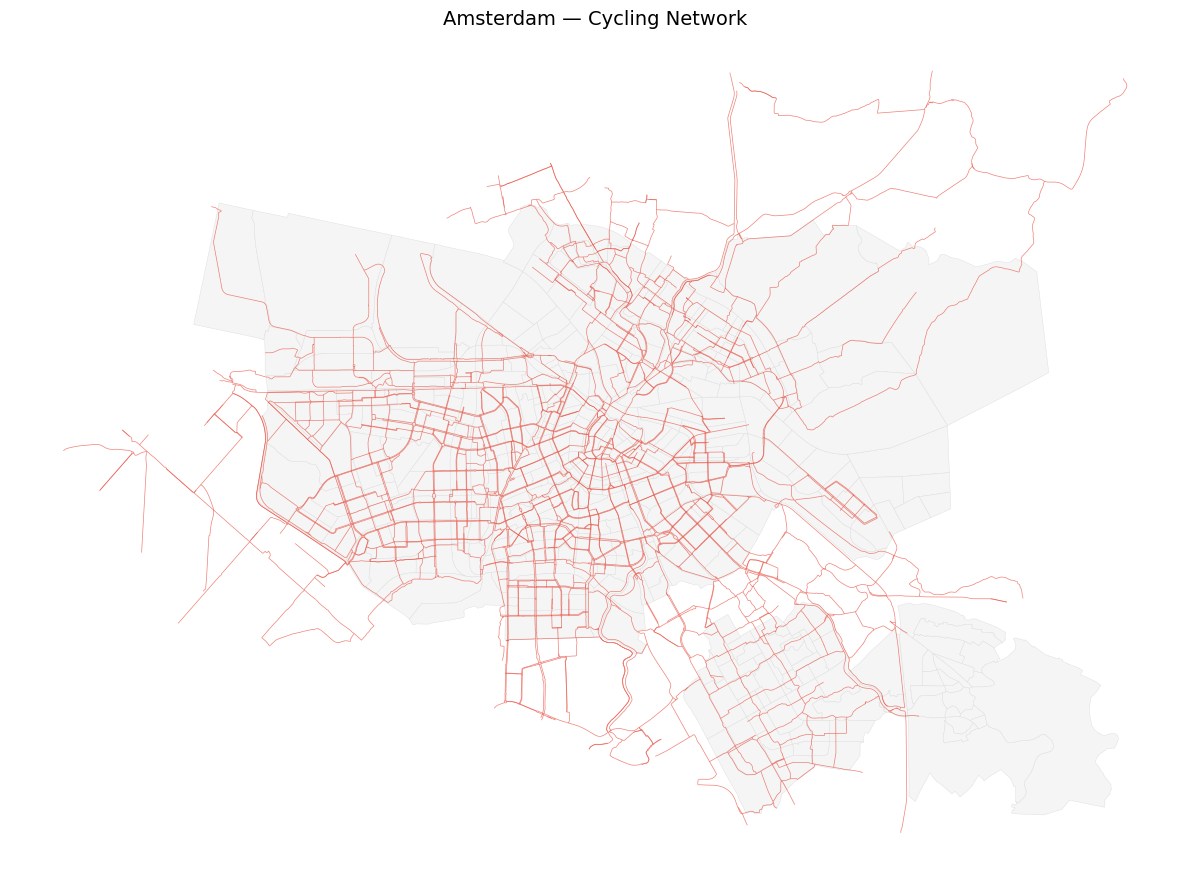

In [6]:
# Carichiamo i buurten come sfondo
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
fietsen_proj = fietsen.to_crs(buurten.crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo quartieri
buurten.plot(
    ax=ax,
    color='#f5f5f5',
    edgecolor='#dddddd',
    linewidth=0.3
)

# Rete ciclabile in rosso
fietsen_proj.plot(
    ax=ax,
    color='#E84C3D',
    linewidth=0.5,
    alpha=0.7
)

ax.set_title('Amsterdam — Cycling Network', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_cycling_map.png', dpi=150, bbox_inches='tight')
plt.show()

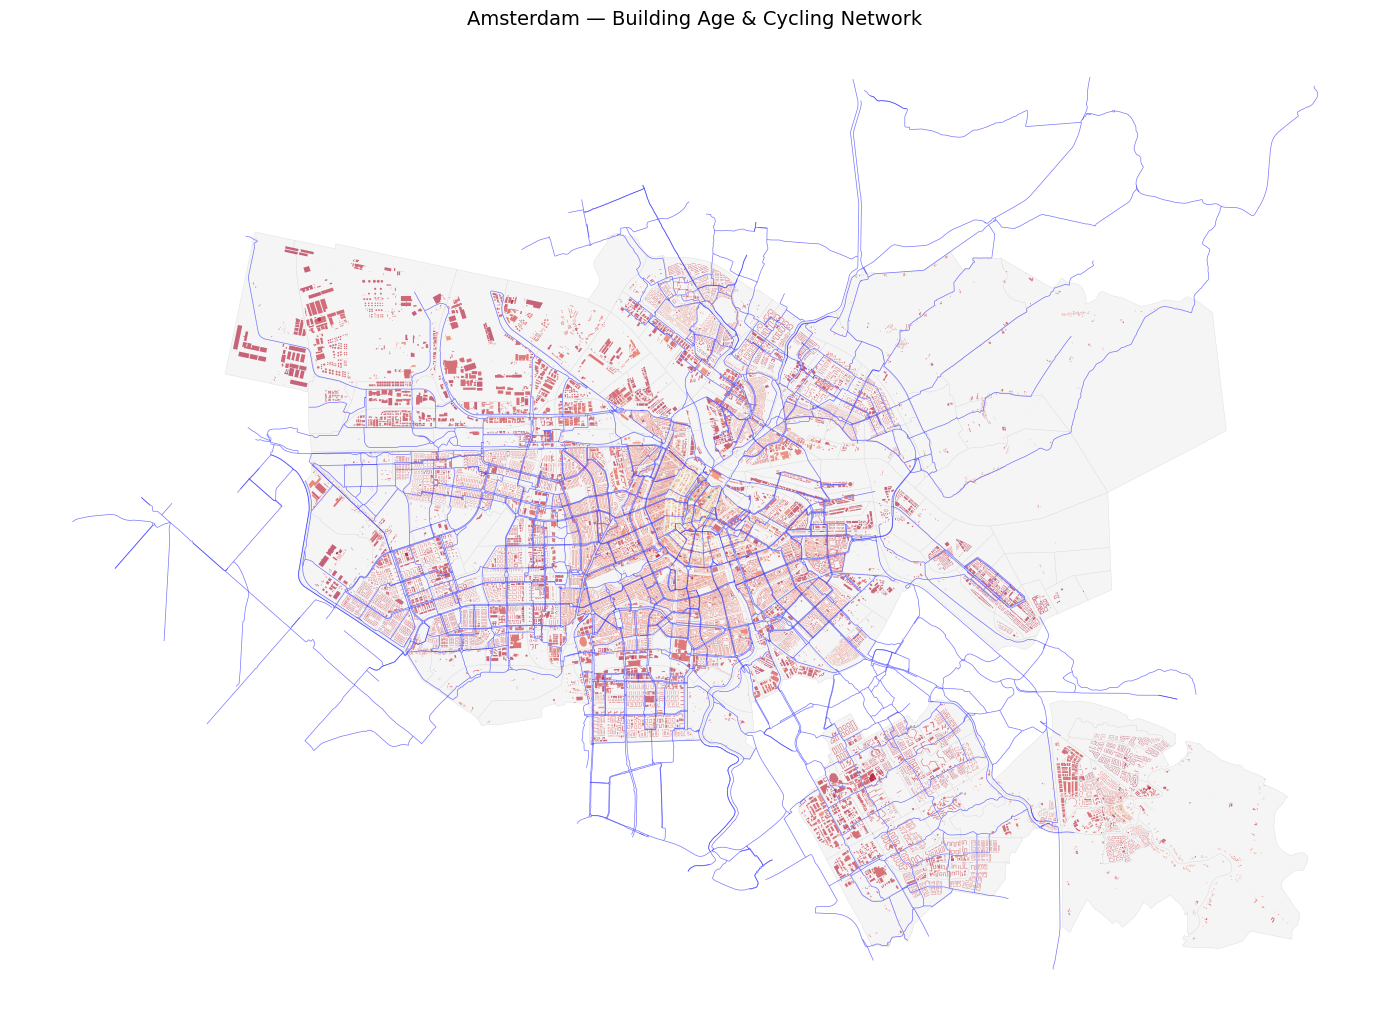

In [7]:
# Carichiamo gli edifici
gdf = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat.json",
                    on_invalid="ignore")

# Assicuriamoci che tutti i layer abbiano lo stesso CRS
gdf = gdf.to_crs(buurten.crs)
fietsen_proj = fietsen.to_crs(buurten.crs)

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# Sfondo quartieri
buurten.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Edifici colorati per anno
gdf[gdf['Bouwjaar'] > 0].plot(
    column='Bouwjaar',
    cmap='RdYlGn_r',
    ax=ax,
    alpha=0.6,
    legend=False
)

# Rete ciclabile sopra
fietsen_proj.plot(ax=ax, color='#1a1aff', linewidth=0.5, alpha=0.6)

ax.set_title('Amsterdam — Building Age & Cycling Network', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_combined.png', dpi=150, bbox_inches='tight')
plt.show()